### Step 1: Clean Data

Process raw data into a clean structured dataframe

In [11]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.io import loadmat

RAW_FILEPATH = "../data/001_raw/P_data.mat"
CLEANED_FILEPATH = "../data/002_cleaned/1s_power_load.parquet"

os.makedirs("../data/001_raw", exist_ok=True)
os.makedirs("../data/002_cleaned", exist_ok=True)

In [5]:
raw_data = loadmat(RAW_FILEPATH)
raw_data

{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN, Created on: Mon Jan 26 17:25:22 2026',
 '__version__': '1.0',
 '__globals__': [],
 'P_data': array([[1925., 1301., 1320., ..., 2123., 2606., 1318.],
        [1922., 1296., 1320., ..., 2126., 2601., 1317.],
        [1921., 1285., 1316., ..., 2121., 2607., 1316.],
        ...,
        [1253., 1315., 1518., ..., 2615., 1321., 1446.],
        [1248., 1315., 1506., ..., 2613., 1320., 1469.],
        [1249., 1317., 1516., ..., 2605., 1320., 1463.]], shape=(86400, 31)),
 'day_data': array([[array(['2025/11/28'], dtype='<U10'),
         array(['2025/11/29'], dtype='<U10'),
         array(['2025/11/30'], dtype='<U10'),
         array(['2025/12/01'], dtype='<U10'),
         array(['2025/12/02'], dtype='<U10'),
         array(['2025/12/03'], dtype='<U10'),
         array(['2025/12/04'], dtype='<U10'),
         array(['2025/12/05'], dtype='<U10'),
         array(['2025/12/06'], dtype='<U10'),
         array(['2025/12/07'], dtype='<U10'),
     

**Restructure Data**:

Transform raw data into a structured dataframe

| Column | Description |
| --- | --- |
| `timestamp` | Timestamp of when the power load was recorded |
| `load` | Power load recorded, in Watts |
| `day_class` | Type of workday (`full`, `half`, `none`) |

In [6]:
# Transform raw data into a dataframe
raw_p_data = raw_data["P_data"]
raw_day_data = raw_data["day_data"]
raw_day_class = raw_data["day_class"]

columns = pd.to_datetime([d[0] for d in raw_day_data.squeeze()])
df = (
    pd.DataFrame(raw_p_data, columns=columns)
    .assign(second_of_day=np.arange(86400))
    .melt(id_vars="second_of_day", var_name="date", value_name="load")
    .assign(
        date=lambda x: pd.to_datetime(x["date"]),
        timestamp=lambda x: x["date"]
        + pd.to_timedelta(x["second_of_day"], unit="s")
    )
    .sort_values("timestamp")
    .reset_index(drop=True)
)

# Add day class labels
day_class_df = pd.DataFrame({
    "date": pd.to_datetime([d[0] for d in raw_day_data.squeeze()]),
    "day_class": [d[0] for d in raw_day_class.squeeze()]
})

df = df.merge(
    day_class_df,
    left_on=pd.to_datetime(df["timestamp"].dt.date),
    right_on="date",
    how="left"
)

df = df[["timestamp", "load", "day_class"]]

print(df.shape)
df.head()

(2678400, 3)


,timestamp,load,day_class
0,2025-11-28 00:00:00,1925.0,full
1,2025-11-28 00:00:01,1922.0,full
2,2025-11-28 00:00:02,1921.0,full
3,2025-11-28 00:00:03,1921.0,full
4,2025-11-28 00:00:04,1926.0,full


**Missing Power Load**:

Missing power load values represent errors in the device recording the power load. For our model approach, we will keep them as `NaN` values because they represent truth of the data. We will filter out missing power load values during training.

Number of missing load values: 14576 (0.54% of dataset)


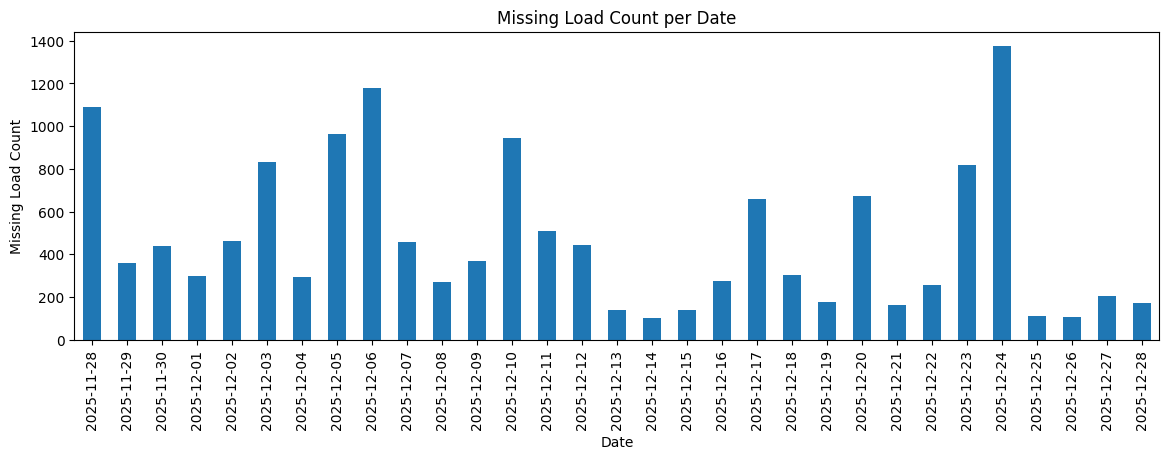

In [7]:
# Check for missing load values
missing_load_df = df[df["load"].isna()]
missing_load_count = missing_load_df.shape[0]
print(f"Number of missing load values: {missing_load_count} ({missing_load_count / df.shape[0] * 100:.2f}% of dataset)")

# Plot missing load count per date (including dates with 0 missing values)
missing_load_count_per_date = missing_load_df.groupby(missing_load_df["timestamp"].dt.date).size()
date_range = pd.date_range(start=df["timestamp"].min().date(), end=df["timestamp"].max().date(), freq="D").date
missing_load_count_per_date = missing_load_count_per_date.reindex(date_range, fill_value=0)
missing_load_count_per_date.plot(kind="bar", figsize=(14, 4))
plt.xlabel("Date")
plt.ylabel("Missing Load Count")
plt.title("Missing Load Count per Date")
plt.show()


**Zero Power Load**:

Zero power load values represent 0 watts recorded at the given time interval. This is an accurate reading of the device and will be left as 0.

Number of missing load values: 2682 (0.10% of dataset)


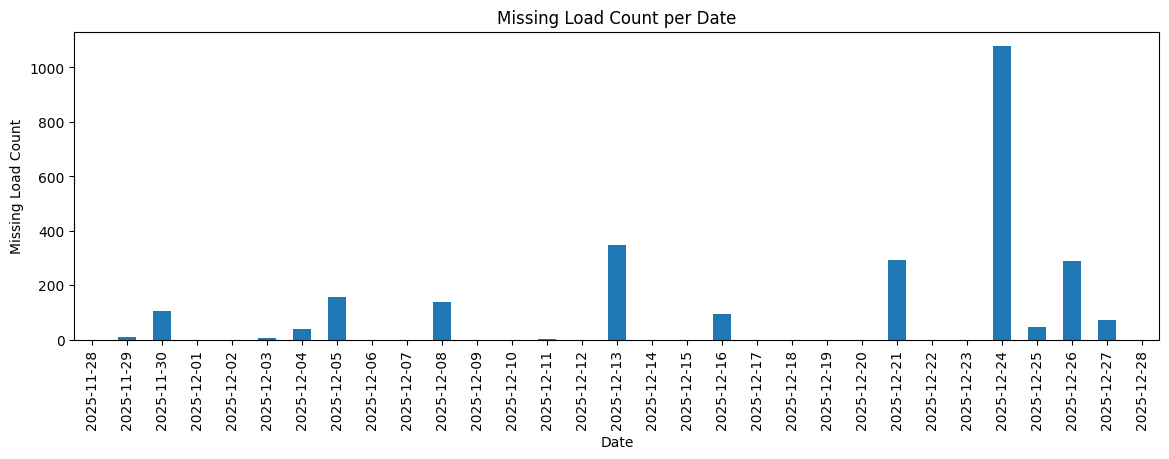

In [8]:
# Check for missing load values
zero_load_df = df[df["load"] == 0]
zero_load_count = zero_load_df.shape[0]
print(f"Number of missing load values: {zero_load_count} ({zero_load_count / df.shape[0] * 100:.2f}% of dataset)")

# Plot missing load count per date (including dates with 0 missing values)
zero_load_count_per_date = zero_load_df.groupby(zero_load_df["timestamp"].dt.date).size()
date_range = pd.date_range(start=df["timestamp"].min().date(), end=df["timestamp"].max().date(), freq="D").date
zero_load_count_per_date = zero_load_count_per_date.reindex(date_range, fill_value=0)
zero_load_count_per_date.plot(kind="bar", figsize=(14, 4))
plt.xlabel("Date")
plt.ylabel("Missing Load Count")
plt.title("Missing Load Count per Date")
plt.show()


**Outliers**

We assume the power load data is accurate and high outliers represent true readings of the machine. There doesn't appear to be any values that seem inaccurate or of concern.

Number of high load values: 26636 (0.99% of dataset)


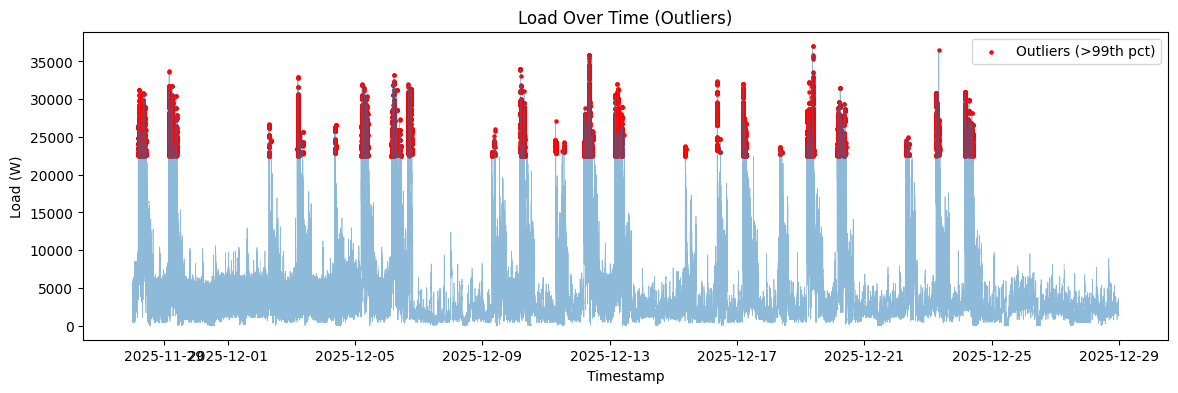

In [9]:
# Identify high load values (e.g. above 99th percentile)
high_load_threshold = df["load"].quantile(0.99)
high_load_df = df[df["load"] > high_load_threshold]
high_load_count = high_load_df.shape[0]
print(f"Number of high load values: {high_load_count} ({high_load_count / df.shape[0] * 100:.2f}% of dataset)")
high_load_df

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 4))
plt.plot(df["timestamp"], df["load"], alpha=0.5, linewidth=0.5)
plt.scatter(high_load_df["timestamp"], high_load_df["load"], color="red", s=5, label="Outliers (>99th pct)")
plt.title("Load Over Time (Outliers)")
plt.xlabel("Timestamp")
plt.ylabel("Load (W)")
plt.legend()
plt.show()

In [10]:
# Save cleaned dataframe
df.to_parquet(CLEANED_FILEPATH, index=False)